In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [4]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')





In [5]:
print("Jumlah data:", len(df))
print("Jumlah data null:\n", df.isnull().sum())

# Isi nilai kosong BMI dengan mean
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

# === 3. ENCODING KATEGORIK ===
le = LabelEncoder()
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    df[col] = le.fit_transform(df[col])

Jumlah data: 5110
Jumlah data null:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


C:\Users\MY ASUS\AppData\Local\Temp\ipykernel_1328\1821775370.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [6]:
X = df.drop(columns=['id', 'stroke'])
y = df['stroke']

# === 5. NORMALISASI FITUR ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# === 6. TRAIN TEST SPLIT ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# === 7. TRAIN MODEL ===
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = model.predict(X_test)

# === 9. EVALUASI MODEL ===
print("\nAkurasi Model: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred))




Akurasi Model: 94.91%

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



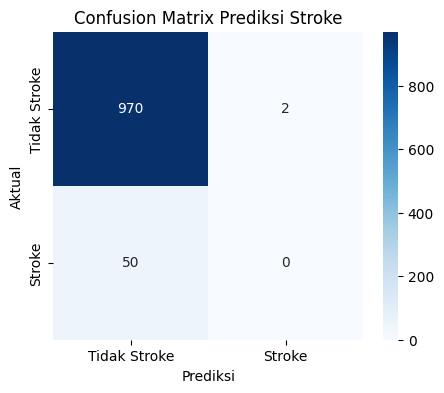

In [10]:
# === 10. CONFUSION MATRIX ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Stroke', 'Stroke'], yticklabels=['Tidak Stroke', 'Stroke'])
plt.title("Confusion Matrix Prediksi Stroke")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

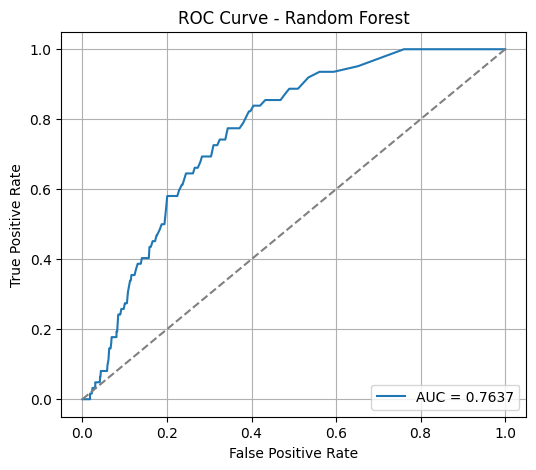


ROC AUC Score: 0.7637


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")


=== Top 10 Feature Importances ===
age                  0.416310
avg_glucose_level    0.179183
bmi                  0.148684
work_type            0.079202
smoking_status       0.053093
Residence_type       0.036464
gender               0.035195
ever_married         0.023266
hypertension         0.016734
heart_disease        0.011869
dtype: float64


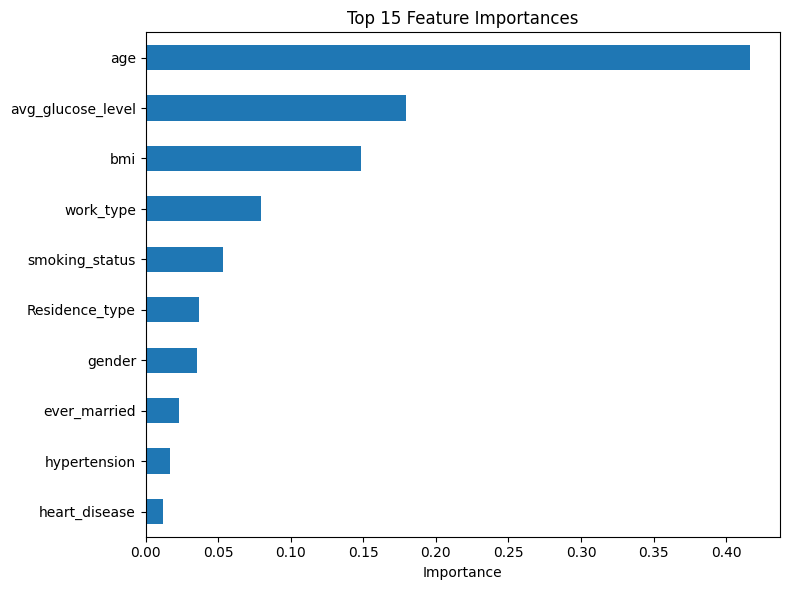

In [9]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n=== Top 10 Feature Importances ===")
print(importances.head(10))

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

C:\Users\MY ASUS\AppData\Local\Temp\ipykernel_1328\2424548213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


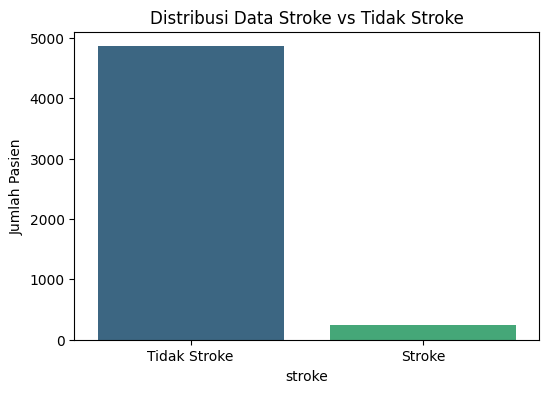

In [11]:
# === 11. VISUALISASI DISTRIBUSI STROKE ===
plt.figure(figsize=(6,4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('Distribusi Data Stroke vs Tidak Stroke')
plt.xticks([0,1], ['Tidak Stroke', 'Stroke'])
plt.ylabel('Jumlah Pasien')
plt.show()